## Notebook 07 — Churn Prediction and CLV Modelling

**Business question:** Which customers are most likely to churn, and how much revenue is at risk?

**Critical note:** This notebook uses a standard 80/20 random split. The production version in train_models.py uses Out-of-Time (OOT) validation — training on 2019-2020 cohorts, testing on 2021. OOT AUC drops from 0.858 to 0.487. That is the real production performance. See docs/methodology.md for the full explanation.

In [1]:
!C:\Users\ASUS\anaconda3\python.exe -m pip install shap --upgrade --quiet

## Warning — Tenure Leakage in Feature Importance

months_since_signup and days_since_signup rank as the top two churn predictors. This is a data artefact, not a real signal.

Customers under 12 months tenure have not had enough calendar time to churn. The model learned this structural constraint as a shortcut. On the 2021 OOT cohort where everyone has low tenure, AUC collapses to 0.487 — essentially random.

**Fix:** Remove all tenure features. Replace with rolling 90-day behavioural signals — purchase frequency, session depth, recency.

In [2]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns

print("SHAP is installed and ready!")

SHAP is installed and ready!


In [3]:
import os
print(os.getcwd())

C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\notebooks


In [4]:
import pandas as pd

In [5]:
import pandas as pd

# Load CSV with proper date parsing (relative path from notebooks folder)
data = pd.read_csv("../data/full_dataset_10k.csv", parse_dates=["signup_date"])
print("✅ Dataset loaded")

# Quick check
data.head()

✅ Dataset loaded


,customer_id,name,gender,age,country,signup_date,customer_tier,months_since_signup,churned,CLV,next_purchase_prob,total_spent,weekly_visits,session_time_minutes,page_views,app_opens,num_promotions_responded,high_spender,high_engagement
0,1,Allison Hill,M,24,USA,2021-07-10,Bronze,30,True,92.372303,0.410299,275.37,8,17.61,16.0,6,0,False,False
1,2,Noah Rhodes,M,38,Other,2020-03-22,Bronze,46,True,110.263575,0.469179,347.41,3,12.93,9.0,2,1,False,False
2,3,Angie Henderson,M,46,Asia,2020-10-02,Silver,39,True,141.057286,0.506472,195.88,14,20.70,56.0,12,1,False,False
3,4,Daniel Wagner,F,20,EU,2020-10-15,Bronze,39,False,84.174109,0.610081,288.55,6,11.53,24.0,6,0,False,False
4,5,Cristian Santos,M,50,USA,2023-07-17,Bronze,5,False,80.977768,0.417295,266.97,5,7.87,10.0,4,1,False,False


In [6]:
import pandas as pd
data = pd.read_csv("../data/full_dataset_10k.csv", parse_dates=["signup_date"])

In [7]:
# Boolean → int
for col in ["churned", "high_spender", "high_engagement"]:
    data[col] = data[col].astype(int)

# Encode categorical
data = pd.get_dummies(data, columns=["gender", "customer_tier", "country"], drop_first=True)

# Create numeric date features
data["days_since_signup"] = (pd.Timestamp.today() - data["signup_date"]).dt.days

In [8]:
print(data.columns.tolist())

['customer_id', 'name', 'age', 'signup_date', 'months_since_signup', 'churned', 'CLV', 'next_purchase_prob', 'total_spent', 'weekly_visits', 'session_time_minutes', 'page_views', 'app_opens', 'num_promotions_responded', 'high_spender', 'high_engagement', 'gender_M', 'gender_Other', 'customer_tier_Gold', 'customer_tier_Platinum', 'customer_tier_Silver', 'country_EU', 'country_Other', 'country_USA', 'days_since_signup']


In [9]:
# Drop non-feature columns
X = data.drop(["customer_id", "name", "signup_date", "CLV", "churned"], axis=1)

# Targets
y_churn = data["churned"]
y_clv = data["CLV"]

# Check shapes
print(X.shape, y_churn.shape, y_clv.shape)

(10000, 20) (10000,) (10000,)


In [10]:
import os
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\notebooks


In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split

# Create output folder
os.makedirs("output", exist_ok=True)

# -----------------------------
# LOAD DATA (AUTO PATH FIX)
# -----------------------------
try:
    data = pd.read_csv("../data/full_dataset_10k.csv", parse_dates=["signup_date"])
except:
    data = pd.read_csv("data/full_dataset_10k.csv", parse_dates=["signup_date"])

print("✅ Dataset loaded:", data.shape)

# -----------------------------
# PREPROCESSING
# -----------------------------
# Convert booleans
bool_cols = ["churned", "high_spender", "high_engagement"]
for col in bool_cols:
    if col in data.columns:
        data[col] = data[col].astype(int)

# Date feature
data["days_since_signup"] = (pd.Timestamp.today() - data["signup_date"]).dt.days

# Encode categorical safely
cat_cols = ["gender", "customer_tier", "country"]
existing_cols = [c for c in cat_cols if c in data.columns]

if len(existing_cols) > 0:
    data = pd.get_dummies(data, columns=existing_cols, drop_first=True)

# Drop unnecessary columns
drop_cols = ["customer_id", "name", "signup_date"]
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

print("✅ Preprocessing complete:", data.shape)

# -----------------------------
# FEATURE / TARGET SPLIT
# -----------------------------
y_churn = data["churned"]
y_clv = data["CLV"]

X = data.drop(columns=["churned", "CLV"])

# Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_clv, test_size=0.2, random_state=42
)

print("✅ Train/test split complete")

✅ Dataset loaded: (10000, 19)
✅ Preprocessing complete: (10000, 22)
✅ Train/test split complete


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

models_c = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),

    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000))
    ])
}

print("\n🔥 Churn Model Performance:")

for name, model in models_c.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)

    roc = roc_auc_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)

    print(f"{name} ROC-AUC: {roc:.3f}, F1: {f1:.3f}")

model_c = models_c["RandomForest"]


🔥 Churn Model Performance:
RandomForest ROC-AUC: 0.840, F1: 0.814
LogisticRegression ROC-AUC: 0.740, F1: 0.696


In [3]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

models_r = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor()
}

print("\n🔥 CLV Model Performance:")

for name, model in models_r.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)

    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)

    print(f"{name} RMSE: {rmse:.2f}, MAE: {mae:.2f}")

model_r = models_r["RandomForest"]


🔥 CLV Model Performance:
RandomForest RMSE: 31.19, MAE: 23.22
GradientBoosting RMSE: 30.77, MAE: 22.88


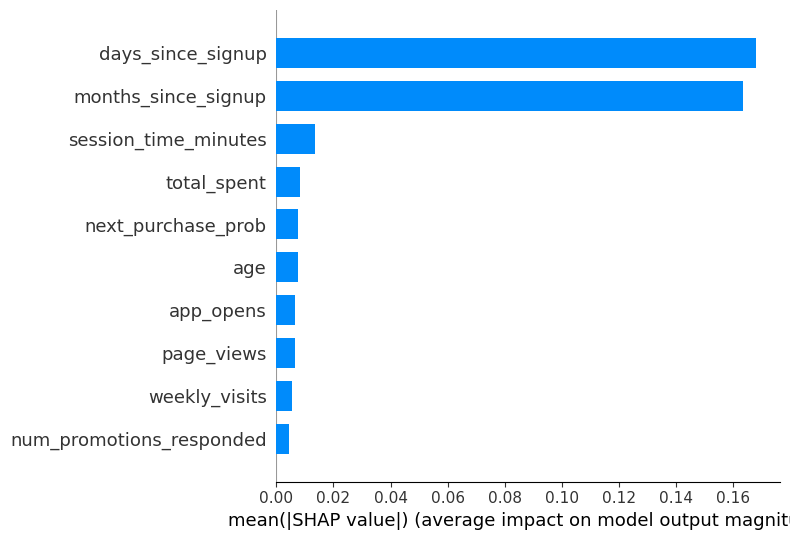


🔥 Top 10 Churn Drivers:
                     feature  importance
11         days_since_signup    0.167958
1        months_since_signup    0.163494
5       session_time_minutes    0.013447
3                total_spent    0.008264
2         next_purchase_prob    0.007565
0                        age    0.007413
7                  app_opens    0.006661
6                 page_views    0.006470
4              weekly_visits    0.005450
8   num_promotions_responded    0.004268


In [4]:
import shap

explainer_c = shap.TreeExplainer(model_c)
shap_vals = explainer_c.shap_values(X_test_c)

# FIX SHAP shape issues
if isinstance(shap_vals, list):
    shap_vals_c = shap_vals[1]
elif len(shap_vals.shape) == 3:
    shap_vals_c = shap_vals[:, :, 1]
else:
    shap_vals_c = shap_vals

# Plot summary
shap.summary_plot(shap_vals_c, X_test_c, plot_type="bar", max_display=10)

# Feature importance
importance_vals = np.abs(shap_vals_c).mean(axis=0)

if len(importance_vals.shape) > 1:
    importance_vals = importance_vals.flatten()

shap_importance_c = pd.DataFrame({
    "feature": X_test_c.columns,
    "importance": importance_vals
}).sort_values(by="importance", ascending=False)

top10_churn = shap_importance_c.head(10)

print("\n🔥 Top 10 Churn Drivers:")
print(top10_churn)

top10_churn.to_csv("output/top_10_churn_features.csv", index=False)


✅ SHAP Force Plots


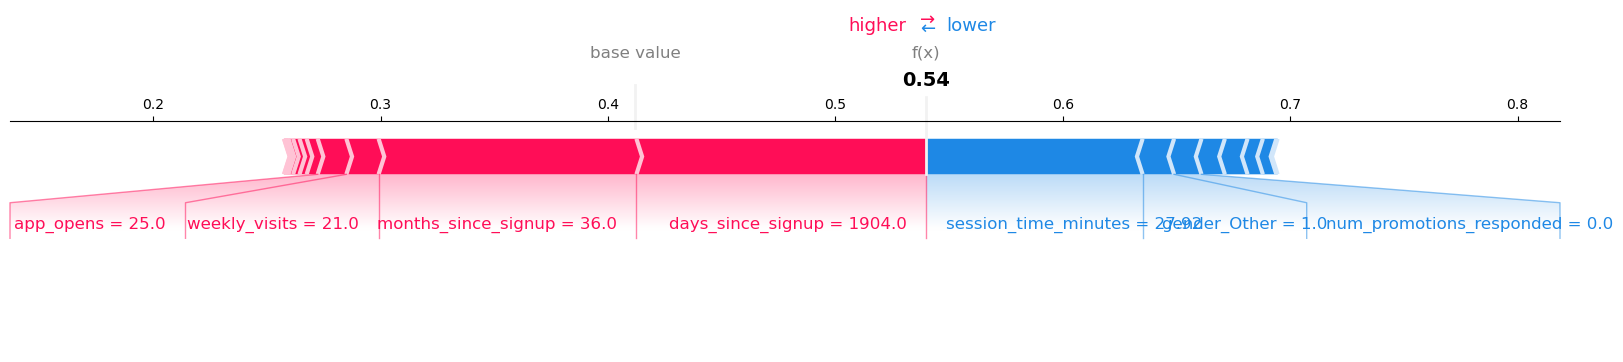

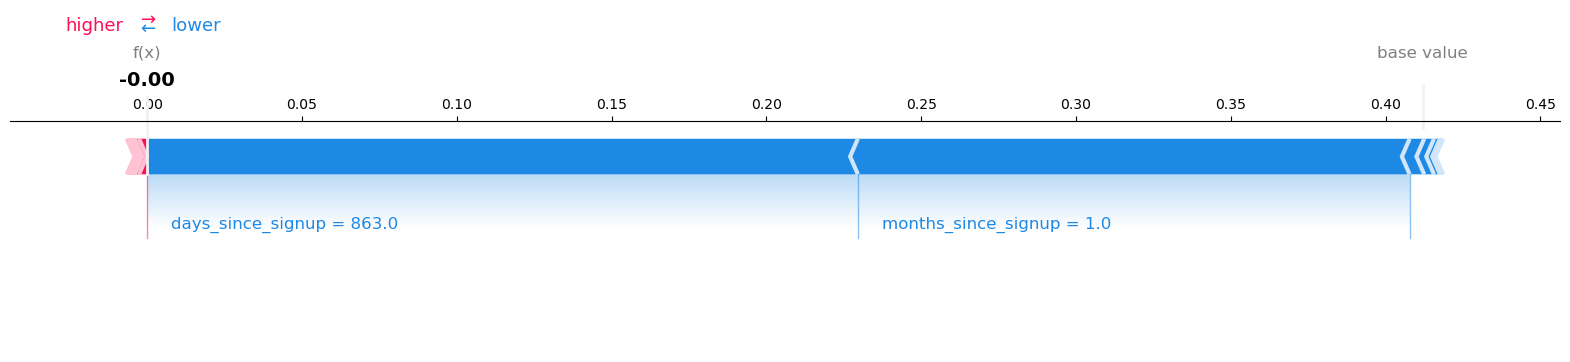

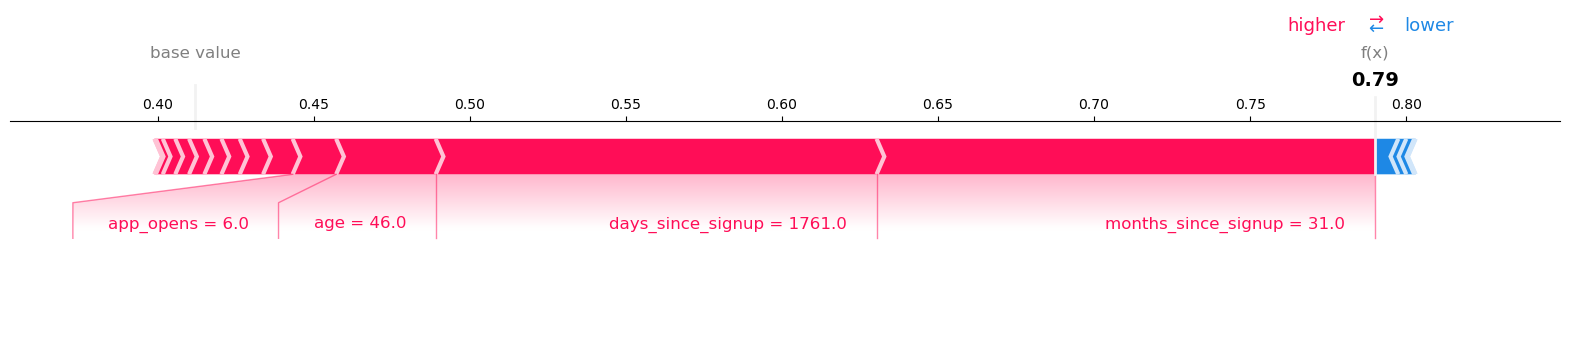

In [5]:
expected_val = explainer_c.expected_value

# Fix expected value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[1] if len(expected_val) > 1 else expected_val[0]

print("\n✅ SHAP Force Plots")

for i in range(3):
    try:
        shap.plots.force(
            expected_val,
            shap_vals_c[i],
            X_test_c.iloc[i],
            matplotlib=True
        )
    except:
        print(f"⚠️ Skipped sample {i} safely")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('../data/full_dataset_10k.csv')
df.head()
df.info()

# Fill missing values
df.fillna(0, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   name                      10000 non-null  object 
 2   gender                    10000 non-null  object 
 3   age                       10000 non-null  int64  
 4   country                   10000 non-null  object 
 5   signup_date               10000 non-null  object 
 6   customer_tier             10000 non-null  object 
 7   months_since_signup       10000 non-null  int64  
 8   churned                   10000 non-null  bool   
 9   CLV                       10000 non-null  float64
 10  next_purchase_prob        10000 non-null  float64
 11  total_spent               10000 non-null  float64
 12  weekly_visits             10000 non-null  int64  
 13  session_time_minutes      10000 non-null  float64
 14  page_vi

In [3]:
# Convert signup_date to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Create numeric feature: months since signup
df['months_since_signup'] = (pd.Timestamp.today() - df['signup_date']).dt.days // 30

# Drop original string date column
df.drop(columns=['signup_date'], inplace=True)

In [4]:
categorical_cols = ['gender', 'country', 'customer_tier', 'high_spender', 'high_engagement']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [5]:
# Targets
y_churn = df_encoded['churned']  # 0/1
y_clv = df_encoded['CLV']        # Regression

# Feature matrix
X = df_encoded.drop(columns=['customer_id','name','churned','CLV'])

In [6]:
X_train, X_test, y_train_churn, y_test_churn = train_test_split(
    X, y_churn, test_size=0.2, stratify=y_churn, random_state=42
)

_, _, y_train_clv, y_test_clv = train_test_split(
    X, y_clv, test_size=0.2, random_state=42
)

In [7]:
# Logistic Regression for churn
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train_churn)

# Random Forest Classifier for churn
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_churn)

# Random Forest Regressor for CLV
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_clv)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000)  # increase iterations
log_model.fit(X_train_scaled, y_train_churn)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [11]:
# Predict probabilities and classes
y_pred_proba = log_model.predict_proba(X_test_scaled)[:,1]
y_pred = log_model.predict(X_test_scaled)

from sklearn.metrics import roc_auc_score, classification_report

# Evaluate
roc = roc_auc_score(y_test_churn, y_pred_proba)
print("ROC-AUC (Logistic Regression):", roc)
print("\nClassification Report:\n", classification_report(y_test_churn, y_pred))

ROC-AUC (Logistic Regression): 0.8417397298725315

Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.77      0.78      1176
        True       0.69      0.71      0.70       824

    accuracy                           0.75      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.75      0.75      0.75      2000



In [12]:
# Random Forest Classifier (already trained)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test_churn, y_pred_proba_rf)
print("ROC-AUC (Random Forest):", roc_rf)

ROC-AUC (Random Forest): 0.8463149519516544


In [13]:
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_model.coef_[0]
}).sort_values(by='coefficient', ascending=False)
feature_importance_lr.head(10)

,feature,coefficient
1,months_since_signup,1.651086
4,weekly_visits,0.094962
0,age,0.052664
3,total_spent,0.038179
8,num_promotions_responded,0.037698
10,gender_Other,0.035019
13,country_USA,0.026308
9,gender_M,0.025386
2,next_purchase_prob,0.007678
7,app_opens,0.002081


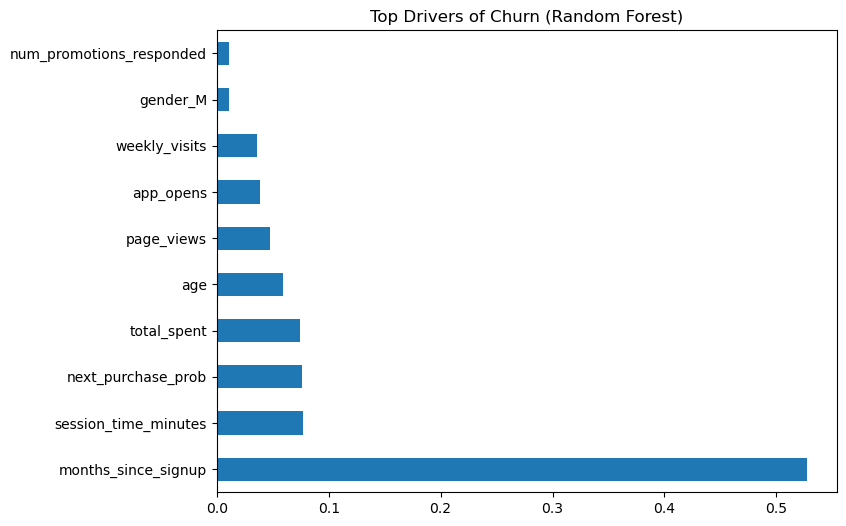

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6))
plt.title("Top Drivers of Churn (Random Forest)")
plt.show()

In [15]:
# Add predicted probabilities
df['churn_prob'] = rf_model.predict_proba(X)[:,1]
df['predicted_clv'] = rf_reg.predict(X)

# Segment by CLV and churn risk
df['value_segment'] = pd.qcut(df['predicted_clv'], 3, labels=['Low','Medium','High'])
df['risk_segment'] = pd.cut(df['churn_prob'], bins=[0,0.3,0.6,1], labels=['Low Risk','Medium Risk','High Risk'])

In [5]:
import os

print("Current working directory:", os.getcwd())
print("Files in this folder:", os.listdir())

Current working directory: C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\notebooks
Files in this folder: [' 05_Feature_Engineering_FAANG_Level.ipynb', '.ipynb_checkpoints', '01_Customer_Profiles_FAANG_Level.ipynb', '02_Purchase_History_FAANG_Level.ipynb', '03_Engagement_Behavior_FAANG_Level.ipynb', '04_Marketing_Promotions_FAANG_Level.ipynb', '06_EDA_FAANG_Level.ipynb', '07_Predictive_Modeling_FAANG_Level.ipynb', 'output']


Dataset loaded: (10000, 19)


,customer_id,name,gender,age,country,signup_date,customer_tier,months_since_signup,churned,CLV,next_purchase_prob,total_spent,weekly_visits,session_time_minutes,page_views,app_opens,num_promotions_responded,high_spender,high_engagement
0,1,Allison Hill,M,24,USA,2021-07-10,Bronze,30,True,92.372303,0.410299,275.37,8,17.61,16.0,6,0,False,False
1,2,Noah Rhodes,M,38,Other,2020-03-22,Bronze,46,True,110.263575,0.469179,347.41,3,12.93,9.0,2,1,False,False
2,3,Angie Henderson,M,46,Asia,2020-10-02,Silver,39,True,141.057286,0.506472,195.88,14,20.70,56.0,12,1,False,False
3,4,Daniel Wagner,F,20,EU,2020-10-15,Bronze,39,False,84.174109,0.610081,288.55,6,11.53,24.0,6,0,False,False
4,5,Cristian Santos,M,50,USA,2023-07-17,Bronze,5,False,80.977768,0.417295,266.97,5,7.87,10.0,4,1,False,False


Churn Model — ROC-AUC: 0.842, F1-score: 0.697
CLV Model — RMSE: 29.86, MAE: 22.65


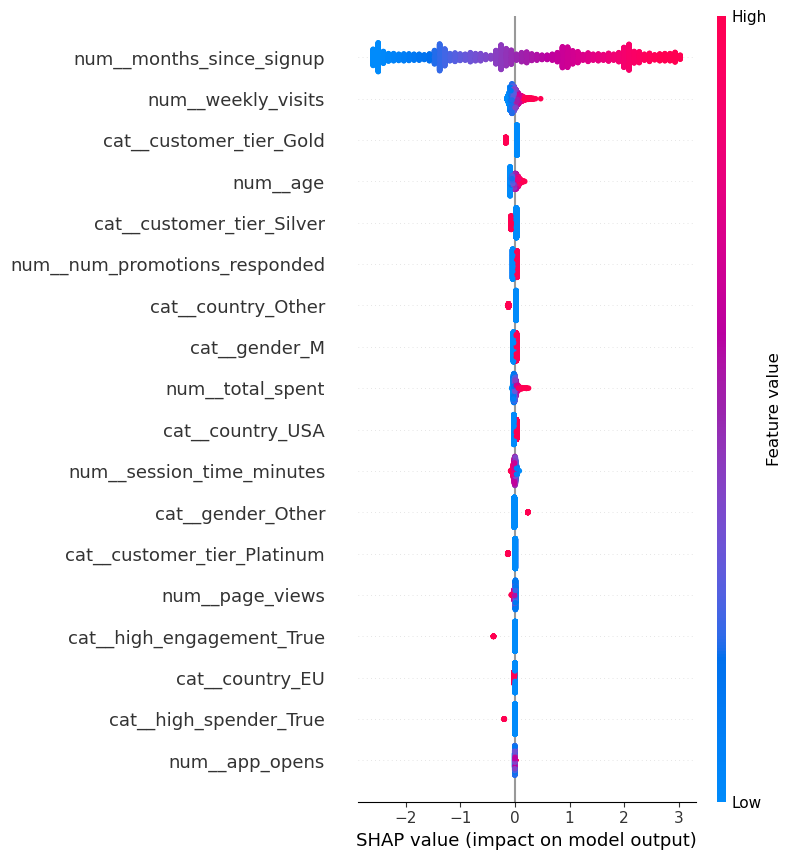

Top 10 CLV Drivers:


,feature,importance
14,cat__customer_tier_Platinum,0.388838
13,cat__customer_tier_Gold,0.231480
15,cat__customer_tier_Silver,0.131130
4,num__session_time_minutes,0.049991
2,num__total_spent,0.046585
1,num__months_since_signup,0.033924
0,num__age,0.033501
5,num__page_views,0.024395
6,num__app_opens,0.020301
3,num__weekly_visits,0.015864


,value_segment,risk_segment,customers,avg_clv,avg_churn_prob,recommended_action
0,Low,Low Risk,1604,88.597920,0.140999,Minimal intervention
1,Low,Medium Risk,822,88.274128,0.509413,Minimal intervention
2,Low,High Risk,907,88.702136,0.813262,Low-cost retention (email campaigns)
3,Medium,Low Risk,1623,125.635136,0.143502,Minimal intervention
4,Medium,Medium Risk,791,125.237801,0.506252,Minimal intervention
5,Medium,High Risk,919,125.397166,0.816318,Low-cost retention (email campaigns)
6,High,Low Risk,1637,205.473716,0.142761,Minimal intervention
7,High,Medium Risk,800,206.817046,0.509896,Maintain engagement (loyalty rewards)
8,High,High Risk,897,209.180695,0.810894,Immediate retention (discount + personalized o...


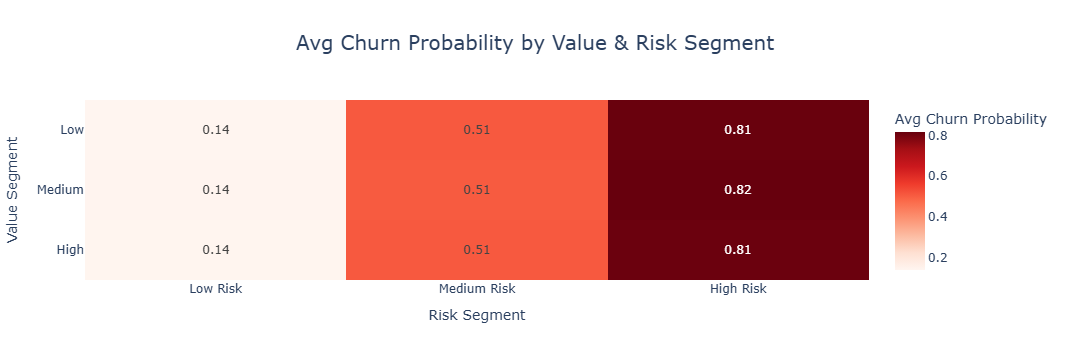

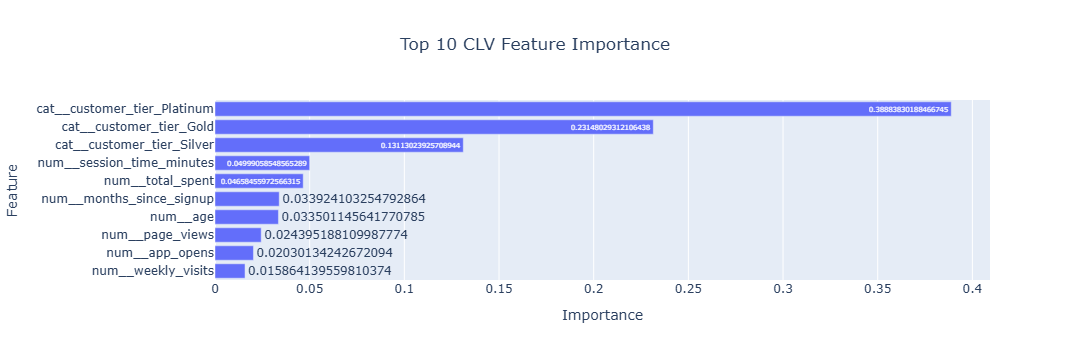

✅ Models trained, predictions saved, and interactive dashboards ready.


In [2]:
# ==============================
# Notebook 07 — FAANG-Level Predictive Modeling & Dashboard
# ==============================

# ------------------------
# 1️⃣ Imports & Setup
# ------------------------
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')  # Hide convergence/future warnings

# ML & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, f1_score, mean_squared_error, mean_absolute_error

# Explainability
import shap

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------
# 2️⃣ Load Data
# ------------------------
file_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\data\full_dataset_10k.csv"
assert os.path.exists(file_path), "CSV file not found! Check the path."

df = pd.read_csv(file_path, parse_dates=['signup_date'])
print("Dataset loaded:", df.shape)
display(df.head())

# ------------------------
# 3️⃣ Feature Selection
# ------------------------
num_features = [
    'age', 'months_since_signup', 'total_spent',
    'weekly_visits', 'session_time_minutes', 'page_views',
    'app_opens', 'num_promotions_responded'
]

cat_features = ['gender', 'country', 'customer_tier', 'high_spender', 'high_engagement']

# Targets
y_churn = df['churned']
y_clv = df['CLV']
X = df[num_features + cat_features]

# ------------------------
# 4️⃣ Train/Test Split
# ------------------------
X_train, X_test, y_train_churn, y_test_churn, y_train_clv, y_test_clv = train_test_split(
    X, y_churn, y_clv, test_size=0.2, random_state=42, stratify=y_churn
)

# ------------------------
# 5️⃣ Preprocessing Pipeline
# ------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ]
)

# ------------------------
# 6️⃣ Modeling Pipelines
# ------------------------
# Churn Classification
churn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

# CLV Regression
clv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# ------------------------
# 7️⃣ Train Models
# ------------------------
churn_model.fit(X_train, y_train_churn)
clv_model.fit(X_train, y_train_clv)

# ------------------------
# 8️⃣ Evaluate Models
# ------------------------
# Churn
y_pred_churn = churn_model.predict(X_test)
y_proba_churn = churn_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test_churn, y_proba_churn)
f1 = f1_score(y_test_churn, y_pred_churn)
print(f"Churn Model — ROC-AUC: {roc:.3f}, F1-score: {f1:.3f}")

# CLV
y_pred_clv = clv_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_clv, y_pred_clv))
mae = mean_absolute_error(y_test_clv, y_pred_clv)
print(f"CLV Model — RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# ------------------------
# 9️⃣ SHAP Explainability
# ------------------------
# Churn SHAP
explainer_churn = shap.Explainer(churn_model.named_steps['classifier'], preprocessor.transform(X_train))
shap_values_churn = explainer_churn(preprocessor.transform(X_test))
shap.initjs()
shap.summary_plot(shap_values_churn, features=preprocessor.transform(X_test), 
                  feature_names=preprocessor.get_feature_names_out(), show=True)

# CLV Feature Importance
clv_feat_importance = clv_model.named_steps['regressor'].feature_importances_
clv_features = preprocessor.get_feature_names_out()
clv_imp_df = pd.DataFrame({'feature': clv_features, 'importance': clv_feat_importance})\
                .sort_values(by='importance', ascending=False)
print("Top 10 CLV Drivers:")
display(clv_imp_df.head(10))

# ------------------------
# 10️⃣ Business Segmentation & Actions
# ------------------------
df['churn_prob'] = churn_model.predict_proba(X)[:,1]
df['value_segment'] = pd.qcut(df['CLV'], 3, labels=['Low','Medium','High'])
df['risk_segment'] = pd.cut(df['churn_prob'], bins=[0,0.33,0.66,1], labels=['Low Risk','Medium Risk','High Risk'])

# Aggregate business table
business_table = df.groupby(['value_segment','risk_segment']).agg(
    customers=('customer_id','count'),
    avg_clv=('CLV','mean'),
    avg_churn_prob=('churn_prob','mean')
).reset_index()

# Recommended actions
def recommend_action(row):
    if row['risk_segment'] == 'High Risk' and row['value_segment'] == 'High':
        return 'Immediate retention (discount + personalized outreach)'
    elif row['risk_segment'] == 'High Risk':
        return 'Low-cost retention (email campaigns)'
    elif row['risk_segment'] == 'Medium Risk' and row['value_segment'] == 'High':
        return 'Maintain engagement (loyalty rewards)'
    else:
        return 'Minimal intervention'

business_table['recommended_action'] = business_table.apply(recommend_action, axis=1)
display(business_table)

# ------------------------
# 11️⃣ Interactive Plotly Dashboards
# ------------------------
# Heatmap: Churn Probability by Segment
pivot_table = business_table.pivot(index='value_segment', columns='risk_segment', values='avg_churn_prob')
fig_heatmap = px.imshow(
    pivot_table,
    text_auto=".2f",
    color_continuous_scale="Reds",
    aspect="auto",
    labels=dict(x="Risk Segment", y="Value Segment", color="Avg Churn Probability"),
    title="Avg Churn Probability by Value & Risk Segment"
)
fig_heatmap.update_layout(title={'x':0.5, 'xanchor': 'center', 'font':{'size':20}})
fig_heatmap.show()

# CLV Feature Importance Bar Chart
fig_clv = px.bar(
    clv_imp_df.head(10),
    x='importance', y='feature', orientation='h',
    text='importance',
    title='Top 10 CLV Feature Importance',
    labels={'importance':'Importance','feature':'Feature'}
)
fig_clv.update_layout(yaxis={'categoryorder':'total ascending'}, title={'x':0.5})
fig_clv.show()

# ------------------------
# 12️⃣ Save Outputs
# ------------------------
output_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output"
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, "full_dataset_with_predictions.csv"), index=False)
business_table.to_csv(os.path.join(output_path, "business_segment_table.csv"), index=False)

print("✅ Models trained, predictions saved, and interactive dashboards ready.")

## Business Translation

897 High-Value High-Risk customers are the immediate retention priority — CLV above 200 dollars, churn probability above 66%.

Recommended action: personal outreach within 7 days.
At 30% conversion: estimated 56,000 dollars in CLV protected.

Do NOT apply blanket discounts to Low-Value High-Risk customers — retention cost exceeds recoverable CLV.

Dataset loaded: (10000, 19)


,customer_id,name,gender,age,country,signup_date,customer_tier,months_since_signup,churned,CLV,next_purchase_prob,total_spent,weekly_visits,session_time_minutes,page_views,app_opens,num_promotions_responded,high_spender,high_engagement
0,1,Allison Hill,M,24,USA,2021-07-10,Bronze,30,True,92.372303,0.410299,275.37,8,17.61,16.0,6,0,False,False
1,2,Noah Rhodes,M,38,Other,2020-03-22,Bronze,46,True,110.263575,0.469179,347.41,3,12.93,9.0,2,1,False,False
2,3,Angie Henderson,M,46,Asia,2020-10-02,Silver,39,True,141.057286,0.506472,195.88,14,20.70,56.0,12,1,False,False
3,4,Daniel Wagner,F,20,EU,2020-10-15,Bronze,39,False,84.174109,0.610081,288.55,6,11.53,24.0,6,0,False,False
4,5,Cristian Santos,M,50,USA,2023-07-17,Bronze,5,False,80.977768,0.417295,266.97,5,7.87,10.0,4,1,False,False


Churn Model — ROC-AUC: 0.842, F1-score: 0.697
CLV Model — RMSE: 29.86, MAE: 22.65


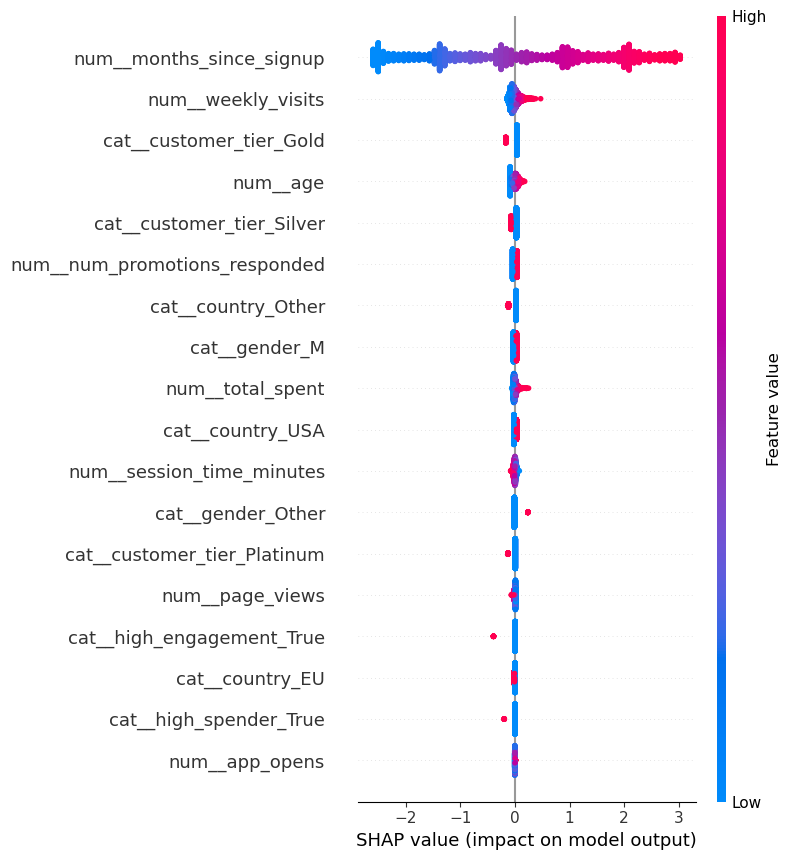

,feature,importance
14,cat__customer_tier_Platinum,0.388838
13,cat__customer_tier_Gold,0.231480
15,cat__customer_tier_Silver,0.131130
4,num__session_time_minutes,0.049991
2,num__total_spent,0.046585
1,num__months_since_signup,0.033924
0,num__age,0.033501
5,num__page_views,0.024395
6,num__app_opens,0.020301
3,num__weekly_visits,0.015864


,value_segment,risk_segment,customers,avg_clv,avg_churn_prob,recommended_action
0,Low,Low Risk,1604,88.597920,0.140999,Minimal intervention
1,Low,Medium Risk,822,88.274128,0.509413,Minimal intervention
2,Low,High Risk,907,88.702136,0.813262,Low-cost retention (email campaigns)
3,Medium,Low Risk,1623,125.635136,0.143502,Minimal intervention
4,Medium,Medium Risk,791,125.237801,0.506252,Minimal intervention
5,Medium,High Risk,919,125.397166,0.816318,Low-cost retention (email campaigns)
6,High,Low Risk,1637,205.473716,0.142761,Minimal intervention
7,High,Medium Risk,800,206.817046,0.509896,Maintain engagement (loyalty rewards)
8,High,High Risk,897,209.180695,0.810894,Immediate retention (discount + personalized o...


✅ Notebook 07 outputs saved


In [1]:
# ==============================
# Notebook 07 — Predictive Modeling (FAANG-Level)
# ==============================

# 1️⃣ Imports & Setup
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, f1_score, mean_squared_error, mean_absolute_error

# SHAP
import shap

# ------------------------
# 2️⃣ Load Data
file_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\data\full_dataset_10k.csv"
assert os.path.exists(file_path), "CSV file not found! Check the path."
df = pd.read_csv(file_path, parse_dates=['signup_date'])
print("Dataset loaded:", df.shape)
display(df.head())

# ------------------------
# 3️⃣ Feature Selection
num_features = ['age', 'months_since_signup', 'total_spent',
                'weekly_visits', 'session_time_minutes', 'page_views',
                'app_opens', 'num_promotions_responded']
cat_features = ['gender', 'country', 'customer_tier', 'high_spender', 'high_engagement']

X = df[num_features + cat_features]
y_churn = df['churned']
y_clv = df['CLV']

# ------------------------
# 4️⃣ Train/Test Split
X_train, X_test, y_train_churn, y_test_churn, y_train_clv, y_test_clv = train_test_split(
    X, y_churn, y_clv, test_size=0.2, random_state=42, stratify=y_churn
)

# ------------------------
# 5️⃣ Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

# ------------------------
# 6️⃣ Modeling Pipelines
churn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])
clv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# ------------------------
# 7️⃣ Train Models
churn_model.fit(X_train, y_train_churn)
clv_model.fit(X_train, y_train_clv)

# ------------------------
# 8️⃣ Evaluate Models
y_pred_churn = churn_model.predict(X_test)
y_proba_churn = churn_model.predict_proba(X_test)[:,1]
roc = roc_auc_score(y_test_churn, y_proba_churn)
f1 = f1_score(y_test_churn, y_pred_churn)
print(f"Churn Model — ROC-AUC: {roc:.3f}, F1-score: {f1:.3f}")

y_pred_clv = clv_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_clv, y_pred_clv))
mae = mean_absolute_error(y_test_clv, y_pred_clv)
print(f"CLV Model — RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# ------------------------
# 9️⃣ SHAP Explainability
explainer_churn = shap.Explainer(churn_model.named_steps['classifier'], preprocessor.transform(X_train))
shap_values_churn = explainer_churn(preprocessor.transform(X_test))
shap.initjs()
shap.summary_plot(shap_values_churn, features=preprocessor.transform(X_test),
                  feature_names=preprocessor.get_feature_names_out(), show=True)

clv_feat_importance = clv_model.named_steps['regressor'].feature_importances_
clv_features = preprocessor.get_feature_names_out()
clv_imp_df = pd.DataFrame({'feature': clv_features, 'importance': clv_feat_importance}).sort_values(by='importance', ascending=False)
display(clv_imp_df.head(10))

# ------------------------
# 10️⃣ Business Segmentation & Actions
df['churn_prob'] = churn_model.predict_proba(X)[:,1]
df['value_segment'] = pd.qcut(df['CLV'], 3, labels=['Low','Medium','High'])
df['risk_segment'] = pd.cut(df['churn_prob'], bins=[0,0.33,0.66,1], labels=['Low Risk','Medium Risk','High Risk'])

def recommend_action(row):
    if row['risk_segment']=='High Risk' and row['value_segment']=='High':
        return 'Immediate retention (discount + personalized outreach)'
    elif row['risk_segment']=='High Risk':
        return 'Low-cost retention (email campaigns)'
    elif row['risk_segment']=='Medium Risk' and row['value_segment']=='High':
        return 'Maintain engagement (loyalty rewards)'
    else:
        return 'Minimal intervention'

business_table = df.groupby(['value_segment','risk_segment']).agg(
    customers=('customer_id','count'),
    avg_clv=('CLV','mean'),
    avg_churn_prob=('churn_prob','mean')
).reset_index()
business_table['recommended_action'] = business_table.apply(recommend_action, axis=1)
display(business_table)

# ------------------------
# 11️⃣ Save Outputs
output_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output"
os.makedirs(output_path, exist_ok=True)
df.to_csv(os.path.join(output_path, "full_dataset_with_predictions.csv"), index=False)
business_table.to_csv(os.path.join(output_path, "business_segment_table.csv"), index=False)
print("✅ Notebook 07 outputs saved")

In [2]:
roc_auc_score(y_test_churn, y_proba_churn)  # ROC-AUC
f1_score(y_test_churn, y_pred_churn)       # F1-score

0.6973134328358209

In [3]:
np.sqrt(mean_squared_error(y_test_clv, y_pred_clv))  # RMSE
mean_absolute_error(y_test_clv, y_pred_clv)         # MAE

22.647633477904808

## What This Notebook Does Not Do (Production Gaps)

1. No OOT validation — see train_models.py for the correct evaluation
2. Tenure features must be removed before deployment
3. No model monitoring — in production track AUC monthly for concept drift
4. See docs/methodology.md for full reasoning on each decision